# Input Testing

  Best fold   : 1
  Model path  : checkpoints\fold_1\best_model.pt
✓ DEM transform loaded from spatial_data.npz
  dem_transform : | 30.00, 0.00, 13462980.00|
| 0.00,-30.00, 1647690.00|
| 0.00, 0.00, 1.00|
  dem_crs_epsg  : 3857
✓ Spatial patches loaded: (6400, 11, 4, 4)

  Model hyperparameters from config:
    embed_dim       : 512
    num_heads       : 4
    num_layers      : 5
    mlp_ratio       : 2.5
    dropout         : 0.05
    rainfall_hidden : 128
    lr              : 3.292759134423613e-05
    weight_decay    : 0.00021137059440645722
  Best macro F1 (saved): 0.5098
✓ Model loaded from: checkpoints\fold_1\best_model.pt
  Device : cuda
  Patches: 6,400 per prediction

[run_inference] triangular_20mm_tp05_drain_soil
  Rasterizing 1011 barangays within DEM extent ...
  Applying mask from manila_box_shape.tif...
  ⚠ Mask alignment: CRS=False, Shape=True
    → Reprojecting mask to match prediction...
  Mask applied: 73,104 / 102,400 pixels inside
✓ Saved → input_testing_vec\triang

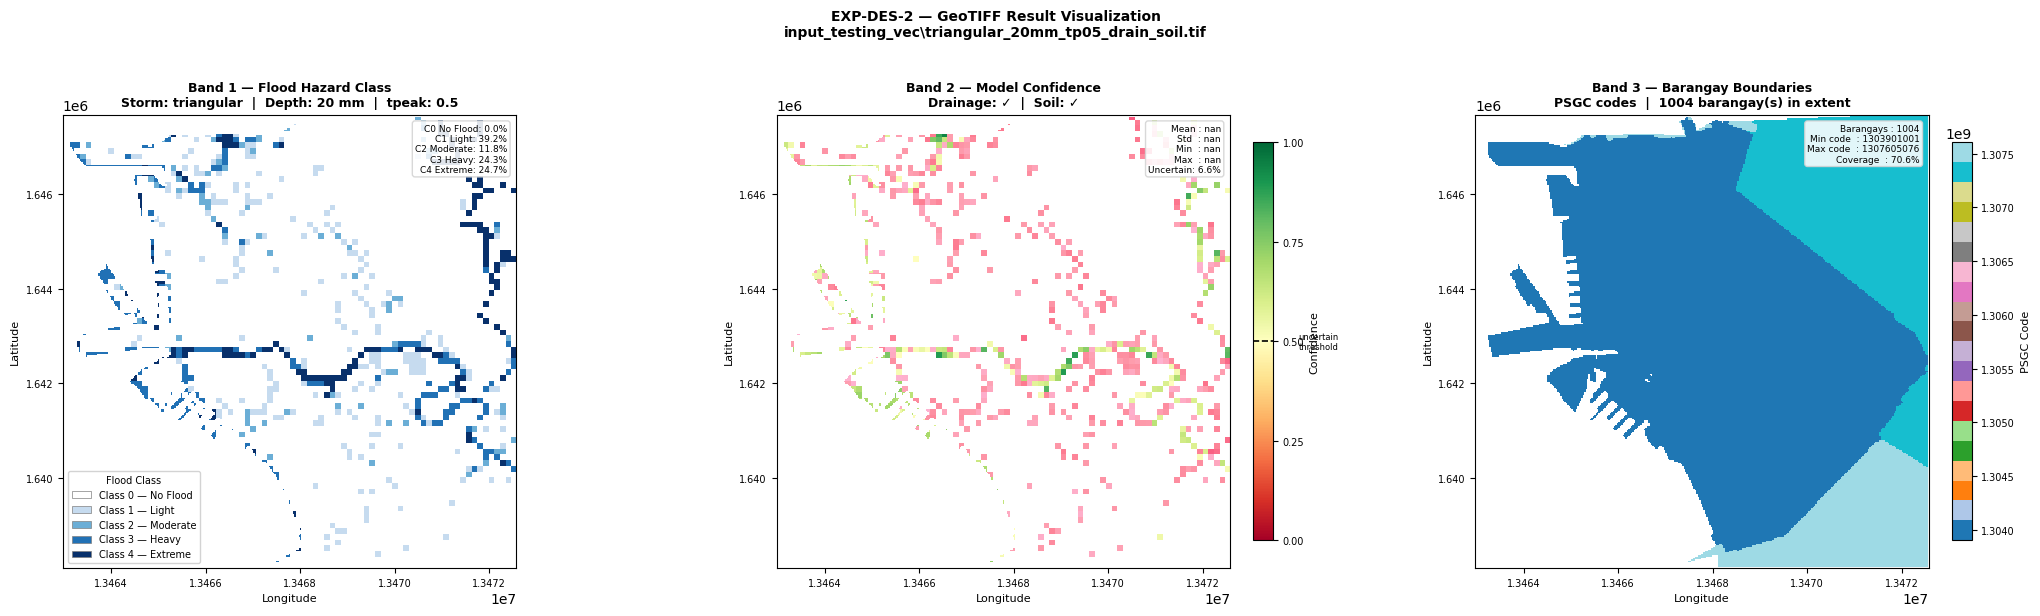

✓ Done  →  input_testing_vec\triangular_20mm_tp05_drain_soil.tif
          input_testing_vec\triangular_20mm_tp05_drain_soil_viz.png


In [2]:
from inference import run_inference, FloodInferenceEngine
from pathlib import Path
import os

repo_root = os.getcwd()
mask_tif_path = os.path.join(repo_root, "manila_box_shape.tif")

engine = FloodInferenceEngine(
    inference_config_path = 'checkpoints/inference_config.json',
    spatial_data_path     = 'checkpoints/spatial_data.npz',
)

result = run_inference(
    engine      = engine,
    storm_type  = 'triangular',
    depth_mm    = 20,
    tpeak       = 0.5,
    hasDrainage = True,
    hasSoil     = True,
    output_dir  = Path('./input_testing_vec'),
    geojson_path = 'manila_barangay_geojson.geojson',
    mask_tif_path = mask_tif_path 
)